#  05. Multi-Task Routing & Model Utilization

**Theme**: Visualize how the Router and Load Balancer define **Model Utilization** across different task types (VQA, OCR, Captioning).

## Key Insight
- Different tasks have different optimal models (e.g., OCR → specialized model, VQA → generalist)
- LB respects these preferences, leading to varying utilization
- We analyze which models do the heavy lifting for each domain

---
## 1. Common Setup

In [1]:
import sys
from pathlib import Path
# Path setup
NOTEBOOK_DIR = Path.cwd()
ROOT_DIR = NOTEBOOK_DIR.parent.parent
ARTEMIS_DIR = ROOT_DIR / 'artemis_final'
CHECKPOINTS_DIR = ARTEMIS_DIR / 'checkpoints'
sys.path.insert(0, str(ROOT_DIR))
sys.path.insert(0, str(ARTEMIS_DIR))

In [9]:
import time 
import matplotlib.pyplot as plt
import pandas as pd

# Imports
from sqlalchemy import create_engine, text
from artemis_final.load_balancer.public_api import (
    load_capacity_config,
    StatsRegistry,
    ArtemisLoadBalancer,
    RouterOutput,
    SchedulingContext,
    ModelCapacityConfig
)
from artemis_final.ares.configs.db_config import DB_URL, TABLES

DB_AVAILABLE = True

# Load Router (Updated)
import torch
from artemis_final.router.public_api import load_router_from_checkpoint

# Detect device
if torch.cuda.is_available():
    DEVICE = 'cuda'
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'
print(f"Device: {DEVICE}")

router = None

Device: mps


In [10]:

try:
    # Load Multitask Reward Router
    ckpt_path = CHECKPOINTS_DIR / 'best_multitask_router_v1.pt'
    if not ckpt_path.exists():
        # Fallback path if CHECKPOINTS_DIR is different or file moved
        ckpt_path = ARTEMIS_DIR / 'checkpoints' / 'best_multitask_router_v1.pt'
    
    if ckpt_path.exists():
        router = load_router_from_checkpoint(checkpoint_path=ckpt_path, router_type="reward", device="cpu")
        print(f" Loaded Reward Router from {ckpt_path.name}")
    else:
        print(f"️ Checkpoint not found at {ckpt_path}")
        
except Exception as e:
    print(f" Failed to load router: {e}")

# Helper to ensure compatibility with LB which expects probs
def get_router_probs(decision):
    if 'probs' in decision:
        return decision['probs']
    if 'rewards' in decision:
        # Convert rewards to soft probabilities for LB compatibility
        import numpy as np
        rewards = decision['rewards']
        vals = np.array(list(rewards.values()))
        exp_vals = np.exp(vals - np.max(vals))
        probs_arr = exp_vals / exp_vals.sum()
        return dict(zip(rewards.keys(), probs_arr.tolist()))
    return {}

if router:
    print(f"   Models: {router.model_names}")
    print(f"   Modes: {router.mode_names}")

[INFO] Using default RouterModelConfig with hidden_dim=256 (compatible with v1 multitask router)
[INFO] Loading model from: /Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/Which_VLM_Router/artemis_final/checkpoints/best_multitask_router_v1.pt
[INFO] Weights loaded successfully (strict=False).
[INFO] Model loaded on device: cpu
[INFO] Text encoder: distilbert-base-uncased
[INFO] Models: ['deepseek_ocr', 'gemma_3_27b', 'qwen2_5_vl_3b', 'qwen2_5_vl_7b', 'qwen3_vl_8b_thinking']
[INFO] Modes: ['accuracy', 'cheap', 'fast', 'balanced']
[INFO] Tasks: 30
 Loaded Reward Router from best_multitask_router_v1.pt
   Models: ['deepseek_ocr', 'gemma_3_27b', 'qwen2_5_vl_3b', 'qwen2_5_vl_7b', 'qwen3_vl_8b_thinking']
   Modes: ['accuracy', 'cheap', 'fast', 'balanced']


In [21]:
# Load samples by task
def load_samples_by_task(n_per_task=20):
    tasks = ['vqa', 'ocr', 'captioning', 'math', 'reasoning']
    all_samples = []
    print("Checking DB availability for samples...", DB_AVAILABLE)
    if DB_AVAILABLE:
        try:
            engine = create_engine(DB_URL)
            with engine.connect() as conn:
                for task in tasks:
                    result = conn.execute(text(f"""
                        SELECT sample_id, prompt_text, router_task 
                        FROM {TABLES['samples']} 
                        WHERE router_task = '{task}' AND prompt_text IS NOT NULL 
                        ORDER BY RANDOM() LIMIT {n_per_task}
                    """))
                    rows = result.fetchall()
                    print(f"Query executed for task '{task}'")
                    if rows:
                        print(f"   Loaded {len(rows)} samples for '{task}'")
                        all_samples.extend([{'sample_id': r[0], 'prompt': r[1], 'router_task': r[2]} for r in rows])
                    else:
                        # Fallback if DB has no samples for this task
                        all_samples.extend([{'sample_id': f'synth_{task}_{i}', 'prompt': f'{task} prompt {i}', 'router_task': task} 
                                          for i in range(n_per_task)])
        except Exception as e:
            print(f"️ DB Error: {e}")
            return generate_synthetic_samples(tasks, n_per_task)
    else:
        return generate_synthetic_samples(tasks, n_per_task)
    
    return all_samples

def generate_synthetic_samples(tasks, n_per_task):
    samples = []
    for task in tasks:
        samples.extend([{'sample_id': f'synth_{task}_{i}', 'prompt': f'{task} prompt {i}', 'router_task': task} for i in range(n_per_task)])
    return samples

samples = load_samples_by_task(20)
print(f" Total samples: {len(samples)}")

Checking DB availability for samples... True
Query executed for task 'vqa'
Query executed for task 'ocr'
Query executed for task 'captioning'
Query executed for task 'math'
Query executed for task 'reasoning'
 Total samples: 100


In [19]:
samples

[{'sample_id': 'synth_vqa_0', 'prompt': 'vqa prompt 0', 'router_task': 'vqa'},
 {'sample_id': 'synth_vqa_1', 'prompt': 'vqa prompt 1', 'router_task': 'vqa'},
 {'sample_id': 'synth_vqa_2', 'prompt': 'vqa prompt 2', 'router_task': 'vqa'},
 {'sample_id': 'synth_vqa_3', 'prompt': 'vqa prompt 3', 'router_task': 'vqa'},
 {'sample_id': 'synth_vqa_4', 'prompt': 'vqa prompt 4', 'router_task': 'vqa'},
 {'sample_id': 'synth_vqa_5', 'prompt': 'vqa prompt 5', 'router_task': 'vqa'},
 {'sample_id': 'synth_vqa_6', 'prompt': 'vqa prompt 6', 'router_task': 'vqa'},
 {'sample_id': 'synth_vqa_7', 'prompt': 'vqa prompt 7', 'router_task': 'vqa'},
 {'sample_id': 'synth_vqa_8', 'prompt': 'vqa prompt 8', 'router_task': 'vqa'},
 {'sample_id': 'synth_vqa_9', 'prompt': 'vqa prompt 9', 'router_task': 'vqa'},
 {'sample_id': 'synth_vqa_10',
  'prompt': 'vqa prompt 10',
  'router_task': 'vqa'},
 {'sample_id': 'synth_vqa_11',
  'prompt': 'vqa prompt 11',
  'router_task': 'vqa'},
 {'sample_id': 'synth_vqa_12',
  'prompt

In [12]:
# Load Router (Updated)
import torch
from artemis_final.router.public_api import load_router_from_checkpoint

# Detect device
if torch.cuda.is_available():
    DEVICE = 'cuda'
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'
print(f"Device: {DEVICE}")

router = None
try:
    # Load Multitask Reward Router
    ckpt_path = CHECKPOINTS_DIR / 'best_multitask_router_v1.pt'
    if not ckpt_path.exists():
        # Fallback path if CHECKPOINTS_DIR is different or file moved
        ckpt_path = ARTEMIS_DIR / 'checkpoints' / 'best_multitask_router_v1.pt'
    
    if ckpt_path.exists():
        router = load_router_from_checkpoint(checkpoint_path=ckpt_path, router_type="reward", device="cpu")
        print(f" Loaded Reward Router from {ckpt_path.name}")
    else:
        print(f"️ Checkpoint not found at {ckpt_path}")
        
except Exception as e:
    print(f" Failed to load router: {e}")

# Helper to ensure compatibility with LB which expects probs
def get_router_probs(decision):
    if 'probs' in decision:
        return decision['probs']
    if 'rewards' in decision:
        # Convert rewards to soft probabilities for LB compatibility
        import numpy as np
        rewards = decision['rewards']
        vals = np.array(list(rewards.values()))
        exp_vals = np.exp(vals - np.max(vals))
        probs_arr = exp_vals / exp_vals.sum()
        return dict(zip(rewards.keys(), probs_arr.tolist()))
    return {}

if router:
    print(f"   Models: {router.model_names}")
    print(f"   Modes: {router.mode_names}")

Device: mps
[INFO] Using default RouterModelConfig with hidden_dim=256 (compatible with v1 multitask router)
[INFO] Loading model from: /Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/Which_VLM_Router/artemis_final/checkpoints/best_multitask_router_v1.pt
[INFO] Weights loaded successfully (strict=False).
[INFO] Model loaded on device: cpu
[INFO] Text encoder: distilbert-base-uncased
[INFO] Models: ['deepseek_ocr', 'gemma_3_27b', 'qwen2_5_vl_3b', 'qwen2_5_vl_7b', 'qwen3_vl_8b_thinking']
[INFO] Modes: ['accuracy', 'cheap', 'fast', 'balanced']
[INFO] Tasks: 30
 Loaded Reward Router from best_multitask_router_v1.pt
   Models: ['deepseek_ocr', 'gemma_3_27b', 'qwen2_5_vl_3b', 'qwen2_5_vl_7b', 'qwen3_vl_8b_thinking']
   Modes: ['accuracy', 'cheap', 'fast', 'balanced']


In [13]:
# Load Balancer & Config
try:
    model_configs = load_capacity_config()
except:
    model_configs = {
        'qwen2_5_vl_7b': ModelCapacityConfig(model_name='qwen2_5_vl_7b', base_latency_ms=800, cost_per_request_usd=0.005),
        'gemma_3_27b': ModelCapacityConfig(model_name='gemma_3_27b', base_latency_ms=2000, cost_per_request_usd=0.01),
        'deepseek_ocr': ModelCapacityConfig(model_name='deepseek_ocr', base_latency_ms=400, cost_per_request_usd=0.002, sla_ms=1000),
    }

lb = ArtemisLoadBalancer(
    model_configs=model_configs,
    stats_registry=StatsRegistry(),
    latency_sla_ms={'default': 3000, 'ocr': 1000, 'vqa': 2000},
    scheduling_mode='capacity_aware',
    simulation_only=True,
)

print(f" Models: {list(model_configs.keys())}")

 Models: ['gemma_3_27b', 'qwen3_vl_8b_thinking', 'qwen2_5_vl_7b', 'qwen2_5_vl_3b', 'deepseek_ocr']


In [ ]:

# === VLM Client Setup ===
from artemis_final.utils.vlm_client_factory import get_vlm_client

# Initialize Client
# simulation_only=False means we try to load real models from config.
# If config is missing or fails, it falls back to Mock.
# Note: In the notebooks below, specific simulation_only flags might override this intention for the Load Balancer,
# but we prepare the client here.
try:
    # Check if 'lb' exists and use its setting, otherwise default to False (Real)
    sim_mode = lb.simulation_only if 'lb' in locals() else False
    vlm_client = get_vlm_client(simulation_only=sim_mode)
    print(f" VLM Client initialized: {type(vlm_client).__name__}")
except Exception as e:
    print(f" Could not initialize VLM client: {e}")
    vlm_client = None


---
## 2. Experiment: Route Tasks & Record Utilization

In [14]:
import time
results = []

for sample in samples:
    task = sample['router_task']
    
    # 1. Get Router Prediction
    if router:
        try:
            rr = router.route(prompt=sample['prompt'], mode='balanced', metadata={'router_task': task})
            probs = get_router_probs(rr)
            preferred = rr['chosen_model']
        except:
            # Fallback
            models = list(model_configs.keys())
            probs = {m: 1.0/len(models) for m in models}
            preferred = models[0]
    else:
        # Synthetic heuristics if router missing
        if task == 'ocr':
            preferred = 'deepseek_ocr' if 'deepseek_ocr' in model_configs else 'qwen2_5_vl_7b'
        elif task == 'math':
            preferred = 'gemma_3_27b' if 'gemma_3_27b' in model_configs else 'qwen2_5_vl_7b'
        else:
            preferred = 'qwen2_5_vl_7b'
        probs = {m: 0.1 for m in model_configs}
        probs[preferred] = 0.8
    
    # 2. Schedule with LB
    ro = RouterOutput(
        sample_id=sample['sample_id'], task_type=task,
        router_probs=probs, preferred_model=preferred, max_prob=probs.get(preferred, 0.5)
    )
    ctx = SchedulingContext(arrival_ts_ms=time.time()*1000, load_profile='task_demo')
    dec = lb.schedule(ro, ctx)
    # === VLM Inference (Injected) ===
    if 'call_vlm' in locals() and call_vlm and vlm_client:
        # Try to get image data
        img_data = sample.get('image_bytes') or sample.get('image')
        if img_data:
            try:
                # If bytes, convert to PIL or pass as is (Client handles it)
                from io import BytesIO
                from PIL import Image
                if isinstance(img_data, bytes):
                    img_input = Image.open(BytesIO(img_data))
                else:
                    img_input = img_data
                    
                print(f"   Invoking VLM ({dec.chosen_model})...")
                vlm_result = vlm_client.vlm.run_image(
                    image=img_input,
                    text=sample['prompt'],
                    models=[dec.chosen_model],
                    max_tokens=200
                )
                
                # Extract result
                model_resp = vlm_result.get(dec.chosen_model, {})
                if model_resp.get('ok'):
                    print(f"   VLM Response: {model_resp.get('response_text')[:100]}...")
                else:
                    print(f"   VLM Error: {model_resp.get('error')}")
                    
            except Exception as e:
                print(f"   VLM call failed: {e}")
        else:
           pass # No image data for VLM


    
    results.append({
        'sample_id': sample['sample_id'],
        'task': task,
        'router_choice': preferred,
        'lb_choice': dec.chosen_model,
        'latency_ms': dec.total_latency_ms,
        'cost_usd': dec.est_cost_usd
    })

Missing 'avg_accuracy' stats for task='vqa', model='qwen2_5_vl_3b'. Using default value.
Missing 'avg_latency_ms' stats for task='vqa', model='qwen2_5_vl_3b'. Using default value.
Missing 'cost_per_request_usd' stats for task='vqa', model='qwen2_5_vl_3b'. Using default value.
Missing 'avg_latency_ms' stats for task='vqa', model='deepseek_ocr'. Using default value.
Missing 'cost_per_request_usd' stats for task='vqa', model='deepseek_ocr'. Using default value.
Missing 'avg_accuracy' stats for task='vqa', model='deepseek_ocr'. Using default value.
Missing 'avg_latency_ms' stats for task='vqa', model='qwen2_5_vl_7b'. Using default value.
Missing 'cost_per_request_usd' stats for task='vqa', model='qwen2_5_vl_7b'. Using default value.
Missing 'avg_accuracy' stats for task='vqa', model='qwen2_5_vl_7b'. Using default value.


Missing 'avg_accuracy' stats for task='ocr', model='qwen2_5_vl_3b'. Using default value.
Missing 'avg_latency_ms' stats for task='ocr', model='qwen2_5_vl_3b'. Using default value.
Missing 'cost_per_request_usd' stats for task='ocr', model='qwen2_5_vl_3b'. Using default value.
Missing 'avg_latency_ms' stats for task='ocr', model='qwen2_5_vl_7b'. Using default value.
Missing 'cost_per_request_usd' stats for task='ocr', model='qwen2_5_vl_7b'. Using default value.
Missing 'avg_accuracy' stats for task='ocr', model='qwen2_5_vl_7b'. Using default value.
Missing 'avg_latency_ms' stats for task='ocr', model='deepseek_ocr'. Using default value.
Missing 'cost_per_request_usd' stats for task='ocr', model='deepseek_ocr'. Using default value.
Missing 'avg_accuracy' stats for task='ocr', model='deepseek_ocr'. Using default value.
Missing 'avg_accuracy' stats for task='captioning', model='qwen2_5_vl_3b'. Using default value.
Missing 'avg_latency_ms' stats for task='captioning', model='qwen2_5_vl_3b'.

In [15]:
df = pd.DataFrame(results)
print("\n Routing Results by Task:")
display(df.groupby(['task', 'lb_choice']).size().unstack(fill_value=0))


 Routing Results by Task:


lb_choice,qwen2_5_vl_3b
task,
captioning,20
math,20
ocr,20
reasoning,20
vqa,20


---
## 3. Visualization: Model Utilization Breakdown

<Figure size 1200x600 with 0 Axes>

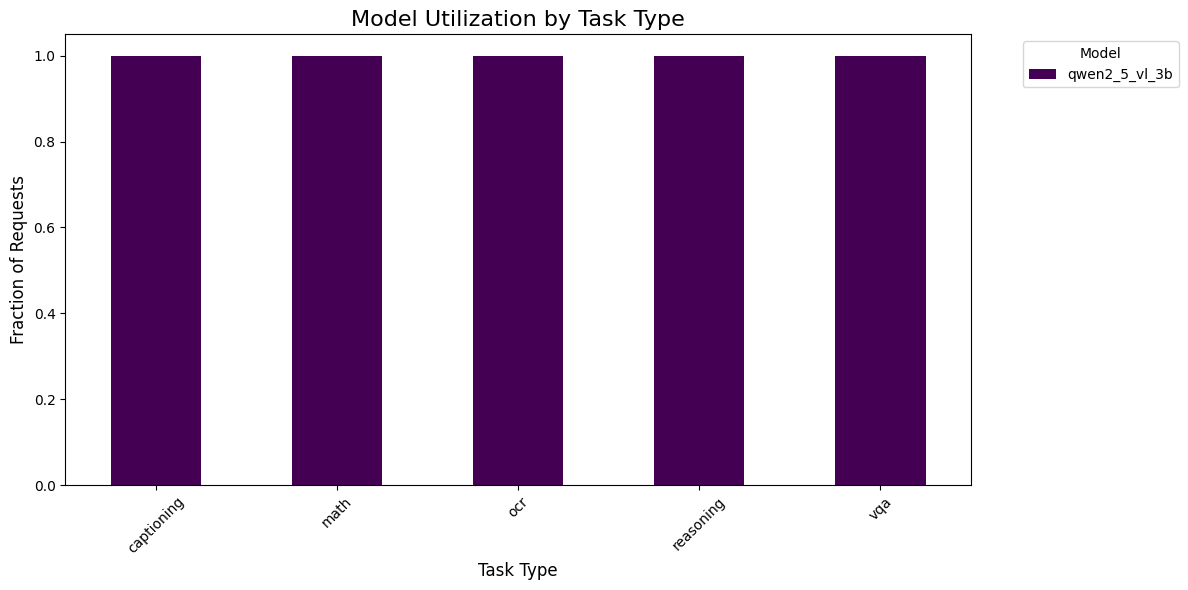


 Insight: Specialized tasks (like OCR) should route to specialized models (e.g. deepseek_ocr),
   while general tasks (VQA) distribute across generalist models.


In [16]:
plt.figure(figsize=(12, 6))

# Utilization by Task
task_model_counts = df.groupby(['task', 'lb_choice']).size().unstack(fill_value=0)
task_model_pct = task_model_counts.div(task_model_counts.sum(axis=1), axis=0)

task_model_pct.plot(kind='bar', stacked=True, colormap='viridis', figsize=(12, 6))
plt.title('Model Utilization by Task Type', fontsize=16)
plt.xlabel('Task Type', fontsize=12)
plt.ylabel('Fraction of Requests', fontsize=12)
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n Insight: Specialized tasks (like OCR) should route to specialized models (e.g. deepseek_ocr),")
print("   while general tasks (VQA) distribute across generalist models.")

---
## 4. Cost Analysis per Task

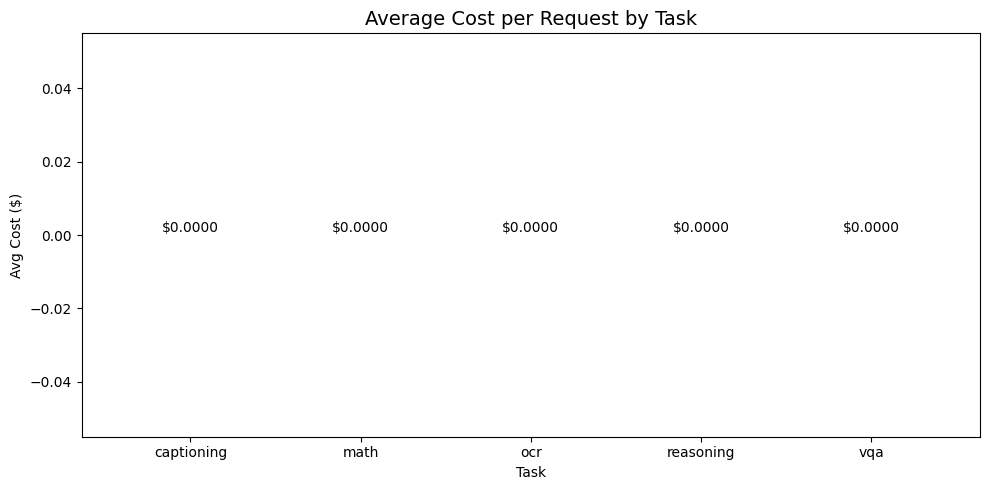

In [17]:
avg_cost = df.groupby('task')['cost_usd'].mean().sort_values()

plt.figure(figsize=(10, 5))
bars = plt.bar(avg_cost.index, avg_cost.values, color='teal', alpha=0.7)
plt.title('Average Cost per Request by Task', fontsize=14)
plt.xlabel('Task')
plt.ylabel('Avg Cost ($)')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'${yval:.4f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()